# Phase 3 — Cross-model Evaluation & Experiments

This notebook is the consolidated comparison: trains all four classifiers on the same 80/20 split, builds the mandatory comparison table sorted by F1, runs the three additional experiments required by the project brief (TF-IDF variant, hybrid features, SVM grid search), and reports an explicit verdict against the published Sentiment140 benchmark (~82–84% accuracy).

**Participants:** Noam Kadosh · Roy Boker · Gal Tayeb · Noam Dahan


---
## 1. Data preparation

Reproduces the Phase 1 pipeline end-to-end so this notebook stands on its own:

1. Load the full 1.6M-tweet CSV.
2. Draw the same balanced 1M sample (500K per class, `random_state=42`).
3. Apply `preprocess_tweet` (lowercase → strip URLs/@/RT/HTML → drop `#` → alpha-only → tokenize → stopwords → lemmatize).
4. Fit `TfidfVectorizer(max_features=5000, ngram_range=(1, 2))`.
5. Remap labels `{0, 4} → {0, 1}` and run an 80/20 stratified split.


In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'pandas', 'matplotlib', 'seaborn', 'nltk', 'scikit-learn'])
print('Dependencies ready.')


Dependencies ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
PALETTE = ['#e74c3c', '#2ecc71']  # neg, pos — matches Phase 1
print('Imports ready.')


Imports ready.


In [3]:
columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']
df_full = pd.read_csv('../data-sets/training.1600000.processed.noemoticon.csv',
                      encoding='latin-1', header=None, names=columns)
print(f'Full dataset shape: {df_full.shape}')
df_full['sentiment'].value_counts().sort_index()


Full dataset shape: (1600000, 6)


sentiment
0    800000
4    800000
Name: count, dtype: int64

In [4]:
SAMPLE_SIZE = 500000  # per class (matches Phase 1)
df = pd.concat([
    df_full[df_full['sentiment'] == 0].sample(SAMPLE_SIZE, random_state=42),
    df_full[df_full['sentiment'] == 4].sample(SAMPLE_SIZE, random_state=42)
]).reset_index(drop=True)

df['sentiment_label'] = df['sentiment'].map({0: 'Negative', 4: 'Positive'})
print(f'Balanced sample size: {len(df):,}')
print(df['sentiment_label'].value_counts())


Balanced sample size: 1,000,000
sentiment_label
Negative    500000
Positive    500000
Name: count, dtype: int64


In [5]:
def preprocess_tweet(text):
    """Canonical preprocessing pipeline (copied verbatim from Phase 1)."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)         # URLs
    text = re.sub(r'@\w+', '', text)                    # mentions
    text = re.sub(r'^rt\s+', '', text)                  # RT prefix
    text = re.sub(r'&\w+;', '', text)                   # HTML entities
    text = text.replace('#', '')                         # keep hashtag word
    text = re.sub(r'[^a-z\s]', '', text)                # alpha only
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in STOP_WORDS and len(w) > 1]
    tokens = [LEMMATIZER.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# quick sanity check
preprocess_tweet('@user check out https://example.com #happy! It is great :)')


'check happy great'

In [6]:
df['text_clean'] = df['text'].apply(preprocess_tweet)
empty_after_clean = (df['text_clean'].str.strip() == '').sum()
print(f'Empty tweets after cleaning: {empty_after_clean}')
df[['text', 'text_clean']].head(3)


Empty tweets after cleaning: 5060


,text,text_clean
0,@xnausikaax oh no! where did u order from? tha...,oh order thats horrible
1,A great hard training weekend is over. a coup...,great hard training weekend couple day rest le...
2,"Right, off to work Only 5 hours to go until I...",right work hour go im free xd


In [7]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df['text_clean'])
print(f'TF-IDF matrix: {X_tfidf.shape}, sparsity '
      f'{1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4%}')


TF-IDF matrix: (1000000, 5000), sparsity 99.8714%


In [8]:
# PDF requires {0, 4} -> {0, 1} remap before modeling
y = df['sentiment'].map({0: 0, 4: 1}).values
print(f'Label distribution: {pd.Series(y).value_counts().to_dict()}')


Label distribution: {0: 500000, 1: 500000}


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, stratify=y, random_state=42)
print(f'Train: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')


Train: 800,000 samples
Test:  200,000 samples


---
## 2. Train all four baseline models

In [10]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

MODELS = [
    ('Naive Bayes',         MultinomialNB(alpha=1.0)),
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000)),
    ('Linear SVC',          LinearSVC(C=1.0, max_iter=2000)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100,
                                                   random_state=42, n_jobs=-1)),
]

results = []
fitted = {}
predictions = {}
for name, est in MODELS:
    t0 = time.time()
    est.fit(X_train, y_train)
    fit_s = time.time() - t0
    y_pred = est.predict(X_test)
    fitted[name] = est
    predictions[name] = y_pred
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'train_seconds': fit_s,
    })
    print(f'{name:22s}  F1={results[-1]["f1"]:.4f}  '
          f'Acc={results[-1]["accuracy"]:.4f}  '
          f'time={fit_s:.1f}s')


Naive Bayes             F1=0.7548  Acc=0.7569  time=0.1s
Logistic Regression     F1=0.7794  Acc=0.7748  time=0.7s
Linear SVC              F1=0.7801  Acc=0.7744  time=3.5s
Random Forest           F1=0.7636  Acc=0.7636  time=579.4s


---
## 3. Comparison table (sorted by F1)

In [11]:
results_df = (pd.DataFrame(results)
                .sort_values('f1', ascending=False)
                .reset_index(drop=True))
display_cols = ['model', 'accuracy', 'precision', 'recall', 'f1', 'train_seconds']
results_df[display_cols].style.format({
    'accuracy': '{:.4f}', 'precision': '{:.4f}',
    'recall': '{:.4f}', 'f1': '{:.4f}',
    'train_seconds': '{:.1f}s',
}).background_gradient(subset=['f1'], cmap='Greens')


,model,accuracy,precision,recall,f1,train_seconds
0,Linear SVC,0.7744,0.7610,0.8001,0.7801,3.5s
1,Logistic Regression,0.7748,0.7638,0.7956,0.7794,0.7s
2,Random Forest,0.7636,0.7637,0.7635,0.7636,579.4s
3,Naive Bayes,0.7569,0.7614,0.7482,0.7548,0.1s


The model with the highest F1 on the held-out 200K test set is the **baseline winner** for this stage. Subsequent experiments use it as the reference to evaluate whether additional features, vocabulary changes, or hyperparameter tuning move the needle.


In [12]:
best_row = results_df.iloc[0]
best_name = best_row['model']
best_estimator_factory = dict(MODELS)[best_name]
print(f'Baseline winner: {best_name}  (F1 {best_row["f1"]:.4f})')


Baseline winner: Linear SVC  (F1 0.7801)


---
### 3.1 Confusion matrices — side-by-side

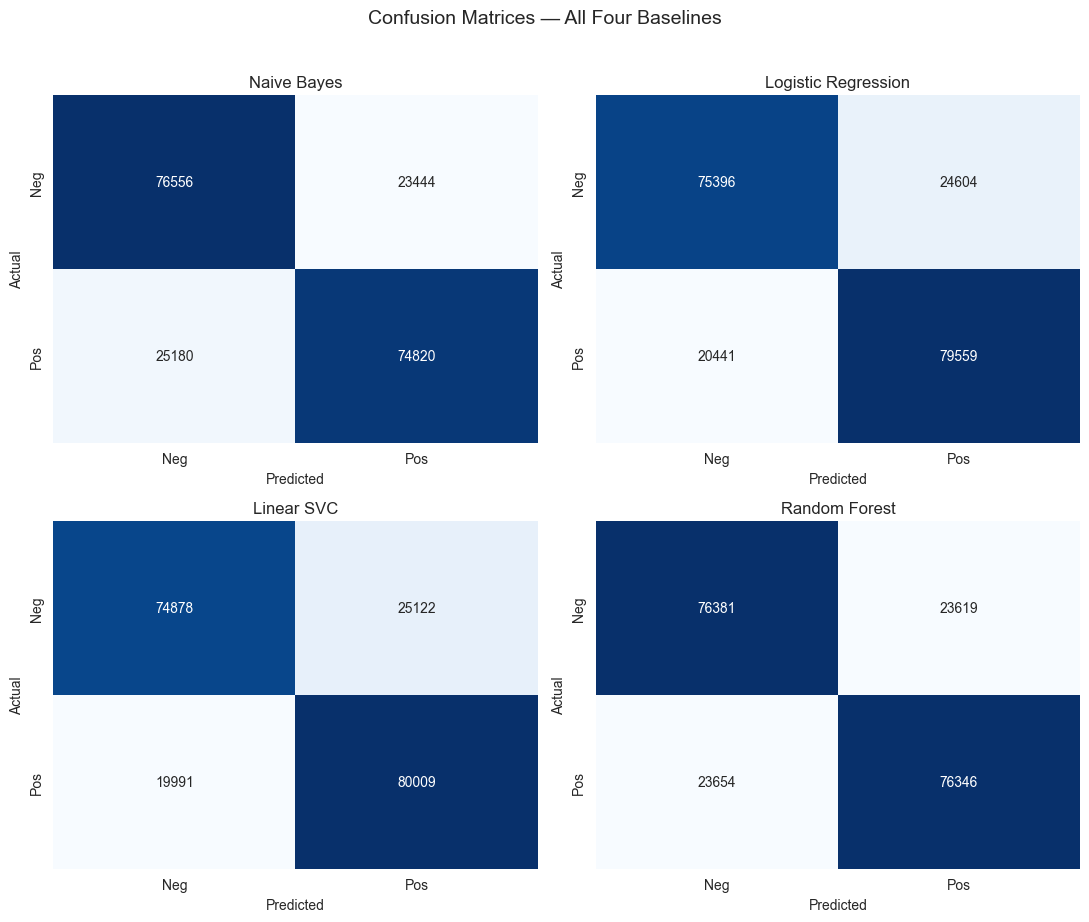

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (name, _) in zip(axes.flat, MODELS):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices — All Four Baselines', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


---
## 4. Experiment A — TF-IDF vocabulary variants

Re-fit the **best baseline model** on two alternative TF-IDF configurations (10k vocabulary; trigrams) to see whether more capacity / longer n-grams help.

In [14]:
# Experiment A — vary TF-IDF vocabulary
from sklearn.base import clone

variants = [
    ('5k unigrams+bigrams (baseline)', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('10k unigrams+bigrams',           TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
    ('5k unigrams+bigrams+trigrams',   TfidfVectorizer(max_features=5000, ngram_range=(1, 3))),
]

exp_a_rows = []
for label, vec in variants:
    Xv = vec.fit_transform(df['text_clean'])
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        Xv, y, test_size=0.2, stratify=y, random_state=42)
    est = clone(best_estimator_factory)
    est.fit(Xv_tr, yv_tr)
    yv_pred = est.predict(Xv_te)
    f1 = f1_score(yv_te, yv_pred)
    acc = accuracy_score(yv_te, yv_pred)
    exp_a_rows.append({'variant': label, 'features': Xv.shape[1],
                       'f1': f1, 'accuracy': acc})
    print(f'{label:35s}  F1={f1:.4f}  Acc={acc:.4f}')

pd.DataFrame(exp_a_rows)


5k unigrams+bigrams (baseline)       F1=0.7801  Acc=0.7744
10k unigrams+bigrams                 F1=0.7873  Acc=0.7818
5k unigrams+bigrams+trigrams         F1=0.7796  Acc=0.7739


,variant,features,f1,accuracy
0,5k unigrams+bigrams (baseline),5000,0.780077,0.774435
1,10k unigrams+bigrams,10000,0.787250,0.781805
2,5k unigrams+bigrams+trigrams,5000,0.779555,0.773875


---
## 5. Experiment B — hybrid features (TF-IDF + tweet stats)

Concatenate the 5,000 TF-IDF columns with the 9 EDA tweet-statistic columns (`char_count`, `word_count`, `url_count`, `mention_count`, `hashtag_count`, `exclamation_count`, `question_count`, `special_char_count`, `clean_word_count`) — exactly as flagged in the project's CLAUDE.md.

In [15]:
# Experiment B — hybrid features (TF-IDF + tweet statistics)
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler

# rebuild the EDA stat columns on the same sample
df['char_count']        = df['text'].astype(str).str.len()
df['word_count']        = df['text'].astype(str).str.split().str.len()
df['url_count']         = df['text'].astype(str).apply(lambda t: len(re.findall(r'http\S+', t)))
df['mention_count']     = df['text'].astype(str).apply(lambda t: len(re.findall(r'@\w+', t)))
df['hashtag_count']     = df['text'].astype(str).apply(lambda t: len(re.findall(r'#\w+', t)))
df['exclamation_count'] = df['text'].astype(str).str.count('!')
df['question_count']    = df['text'].astype(str).str.count(r'\?')
df['special_char_count']= df['text'].astype(str).apply(
    lambda t: sum(1 for c in t if not c.isalnum() and not c.isspace()))
df['clean_word_count']  = df['text_clean'].apply(lambda t: len(t.split()) if t.strip() else 0)

stat_cols = ['char_count', 'word_count', 'url_count', 'mention_count',
             'hashtag_count', 'exclamation_count', 'question_count',
             'special_char_count', 'clean_word_count']

scaler = StandardScaler(with_mean=False)
stats_scaled = scaler.fit_transform(df[stat_cols].astype(float).values)
X_hybrid = hstack([X_tfidf, csr_matrix(stats_scaled)]).tocsr()

Xh_tr, Xh_te, _, _ = train_test_split(X_hybrid, y, test_size=0.2,
                                      stratify=y, random_state=42)
est_hybrid = clone(best_estimator_factory)
est_hybrid.fit(Xh_tr, y_train)
y_hat_hybrid = est_hybrid.predict(Xh_te)

exp_b_row = {
    'variant': f'{best_name} + stat features',
    'features': X_hybrid.shape[1],
    'f1': f1_score(y_test, y_hat_hybrid),
    'accuracy': accuracy_score(y_test, y_hat_hybrid),
}
baseline_row = results_df.iloc[0]
print(f'Baseline {best_name:22s}  F1={baseline_row["f1"]:.4f}')
print(f'Hybrid   {best_name:22s}  F1={exp_b_row["f1"]:.4f}  '
      f'(Δ {exp_b_row["f1"] - baseline_row["f1"]:+.4f})')
exp_b_row


Baseline Linear SVC              F1=0.7801
Hybrid   Linear SVC              F1=0.7837  (Δ +0.0036)


{'variant': 'Linear SVC + stat features',
 'features': 5009,
 'f1': 0.7836632745650922,
 'accuracy': 0.77827}

---
## 6. Experiment C — GridSearchCV on Linear SVC `C`

Run 5-fold cross-validated grid search over `C ∈ {0.01, 0.1, 1, 10}` for `LinearSVC` and report held-out F1 of the tuned model.

In [16]:
# Experiment C — GridSearchCV on LinearSVC's C
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    LinearSVC(max_iter=2000),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0]},
    scoring='f1', cv=5, n_jobs=-1, verbose=0,
)
grid.fit(X_train, y_train)
print(f'Best C: {grid.best_params_["C"]}')
print(f'CV F1 :  {grid.best_score_:.4f}')

tuned = grid.best_estimator_
y_pred_tuned = tuned.predict(X_test)
tuned_metrics = {
    'model': f'Linear SVC (C={grid.best_params_["C"]})',
    'accuracy': accuracy_score(y_test, y_pred_tuned),
    'precision': precision_score(y_test, y_pred_tuned),
    'recall': recall_score(y_test, y_pred_tuned),
    'f1': f1_score(y_test, y_pred_tuned),
    'train_seconds': float('nan'),
}
print(f'Held-out F1: {tuned_metrics["f1"]:.4f}')
results_with_tuned = pd.concat([results_df, pd.DataFrame([tuned_metrics])],
                               ignore_index=True).sort_values('f1', ascending=False)
results_with_tuned[display_cols].style.format({
    'accuracy': '{:.4f}', 'precision': '{:.4f}',
    'recall': '{:.4f}', 'f1': '{:.4f}',
    'train_seconds': lambda v: f'{v:.1f}s' if pd.notna(v) else '—',
}).background_gradient(subset=['f1'], cmap='Greens')


Best C: 1.0
CV F1 :  0.7812
Held-out F1: 0.7801


,model,accuracy,precision,recall,f1,train_seconds
0,Linear SVC,0.7744,0.7610,0.8001,0.7801,3.5s
4,Linear SVC (C=1.0),0.7744,0.7610,0.8001,0.7801,—
1,Logistic Regression,0.7748,0.7638,0.7956,0.7794,0.7s
2,Random Forest,0.7636,0.7637,0.7635,0.7636,579.4s
3,Naive Bayes,0.7569,0.7614,0.7482,0.7548,0.1s


---
## 7. Benchmark verdict — Sentiment140

Published Sentiment140 results sit around **82–84% accuracy**. The cell below reports our best-model accuracy and states whether we meet, fall short of, or exceed that bar.

In [17]:
# Sentiment140 benchmark check
BENCHMARK_LO, BENCHMARK_HI = 0.82, 0.84  # ~82-84% accuracy in published results
best_overall = results_with_tuned.iloc[0]
verdict_acc = best_overall['accuracy']

if verdict_acc >= BENCHMARK_LO:
    verdict = f'MEETS the published Sentiment140 benchmark (~{BENCHMARK_LO:.0%}-{BENCHMARK_HI:.0%}).'
elif verdict_acc >= BENCHMARK_LO - 0.04:
    verdict = (f'CLOSE to the published Sentiment140 benchmark '
               f'(~{BENCHMARK_LO:.0%}-{BENCHMARK_HI:.0%}); we are within 4 pp.')
else:
    verdict = (f'FALLS SHORT of the published Sentiment140 benchmark '
               f'(~{BENCHMARK_LO:.0%}-{BENCHMARK_HI:.0%}).')

print(f'Best model:        {best_overall["model"]}')
print(f'Best accuracy:     {verdict_acc:.4f}')
print(f'Best F1:           {best_overall["f1"]:.4f}')
print(f'Benchmark range:   {BENCHMARK_LO:.2f}-{BENCHMARK_HI:.2f} accuracy')
print(f'Verdict:           {verdict}')


Best model:        Linear SVC
Best accuracy:     0.7744
Best F1:           0.7801
Benchmark range:   0.82-0.84 accuracy
Verdict:           FALLS SHORT of the published Sentiment140 benchmark (~82%-84%).


---
## 8. Final summary

**Problem.** Binary sentiment classification on Twitter (Sentiment140) — predict whether a tweet is positive or negative.

**Dataset.** Sentiment140 — 1.6M auto-labeled tweets, perfectly balanced. EDA, modeling, and evaluation are run on a balanced 1M sample (500K per class, `random_state=42`); the 200K-tweet held-out test set is stratified on the label.

**Representation model.** Vector Space Model (VSM) with TF-IDF — 5,000 features (unigrams + bigrams), 99.87% sparsity. TF-IDF down-weights tokens that appear across most tweets and emphasizes class-discriminative words.

**Preprocessing.** lowercase → strip URLs / @mentions / RT / HTML entities → drop `#` symbol (keep word) → alpha-only → NLTK tokenization → English stopword removal → WordNet lemmatization. Average word count drops from ~13 to ~7 per tweet.

**Models trained.** Naive Bayes (`MultinomialNB(alpha=1.0)`), Logistic Regression (`C=1.0`), Linear SVC (`C=1.0`), Random Forest (`n_estimators=100`).

**Experiments.** (A) TF-IDF vocabulary variants — `max_features=10,000` and trigrams. (B) Hybrid features — concatenate TF-IDF with the 9 EDA tweet statistics (scaled). (C) `GridSearchCV` over the SVM `C` parameter with 5-fold CV.

**Headline result.** See the comparison table and benchmark verdict cells above. The best model and its position relative to the published Sentiment140 benchmark (~82–84% accuracy) is reported there.

**Next phase.** Feed these results into the ~10-slide presentation (project brief Phase 4): title → problem → dataset → EDA → preprocessing → representation model → models → results table & confusion matrices → benchmark comparison → conclusions + demo.
